## Explore house prices data

Get to know your data before you build any model:
- Load & shape check — sizes, dtypes, duplicate rows, first/last rows.
- Target distribution — SalePrice and log1p(SalePrice), skew/kurtosis.
- Missingness map — % missing per column, true-NA-as-category vs genuinely missing.
- Descriptive stats & sanity checks — describe(), scale differences, impossible values (e.g. YearBuilt > YrSold), zero-inflated columns.
- Dtype pass — catch numeric-coded categoricals (MSSubClass).
- Univariate distributions — histograms/boxplots for key numerics, bar charts for key categoricals.
- Numeric vs target — correlation table/heatmap, top movers.
- Categorical vs target — boxplots for Neighborhood, ExterQual, KitchenQual, etc.
- Outliers — known Ames outliers (large GrLivArea, low SalePrice).
- Train/test consistency — categorical levels in test not seen in train.
- Insights & decisions — markdown summary translating all of the above into concrete ml.py choices.



In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
train = pd.read_csv("data/train.csv", na_values=["NA"], keep_default_na=False)
test = pd.read_csv("data/test.csv", na_values=["NA"], keep_default_na=False)

In [5]:
pd.set_option("display.max_columns", 100)    # show all the columns

print("train shape:", train.shape)
print("test shape: ", test.shape)

train shape: (1460, 81)
test shape:  (1459, 80)


In [25]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,None,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


### EDA is done on train dataset only

In [7]:
print("duplicate rows in train (excl. Id):", train.drop(columns="Id").duplicated().sum())

train.dtypes.value_counts()

duplicate rows in train (excl. Id): 0


str        43
int64      35
float64     3
Name: count, dtype: int64

In [8]:
pd.concat([train.head(3), train.tail(3)])


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,None,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,NaN,Attchd,1950.0,Unf,1,240,TA,TA,Y,366,0,112,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,6,1965,1965,Gable,CompShg,HdBoard,HdBoard,None,0.0,Gd,TA,CBlock,TA,TA,No,BLQ,830,LwQ,290,136,1256,GasA,Gd,Y,SBrkr,1256,0,0,1256,1,0,1,1,3,1,TA,6,Typ,0,NaN,Attchd,1965.0,Fin,1,276,TA,TA,Y,736,68,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


## 2. Target (SalePrice) distribution

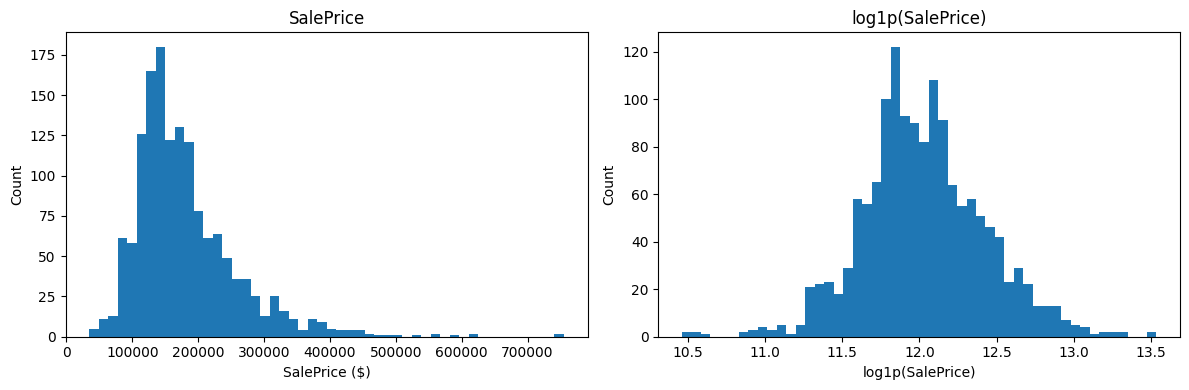

SalePrice      skew: 1.883  kurtosis: 6.536
log1p(SalePrice) skew: 0.121  kurtosis: 0.810


In [9]:
log_saleprice = np.log1p(train["SalePrice"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train["SalePrice"], bins=50)
axes[0].set_title("SalePrice")
axes[0].set_xlabel("SalePrice ($)")
axes[0].set_ylabel("Count")
axes[1].hist(log_saleprice, bins=50)
axes[1].set_title("log1p(SalePrice)")
axes[1].set_xlabel("log1p(SalePrice)")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

print("SalePrice      skew: %.3f  kurtosis: %.3f" % (train["SalePrice"].skew(), train["SalePrice"].kurt()))
print("log1p(SalePrice) skew: %.3f  kurtosis: %.3f" % (log_saleprice.skew(), log_saleprice.kurt()))


SalePrice plot heavily skew to the right, implying few very expensive houses pulling the distribution. log1p(SalePrice) on the other hand is close to normal.
That validates the 'PLAN.md' decision to train on log1p(SalePrice) rather than raw price; a linear/tree model will behave much better on the near-symmetric log target, and RMSE on the log scale makes sense as the reported metric.

## 3. Missingness map

`data_description.txt` documents `NA` as a real category ("no basement", "no garage", ...) for a specific set of columns. Those should become an explicit "None" category at train time, not be imputed. Everything else missing is genuinely missing data.


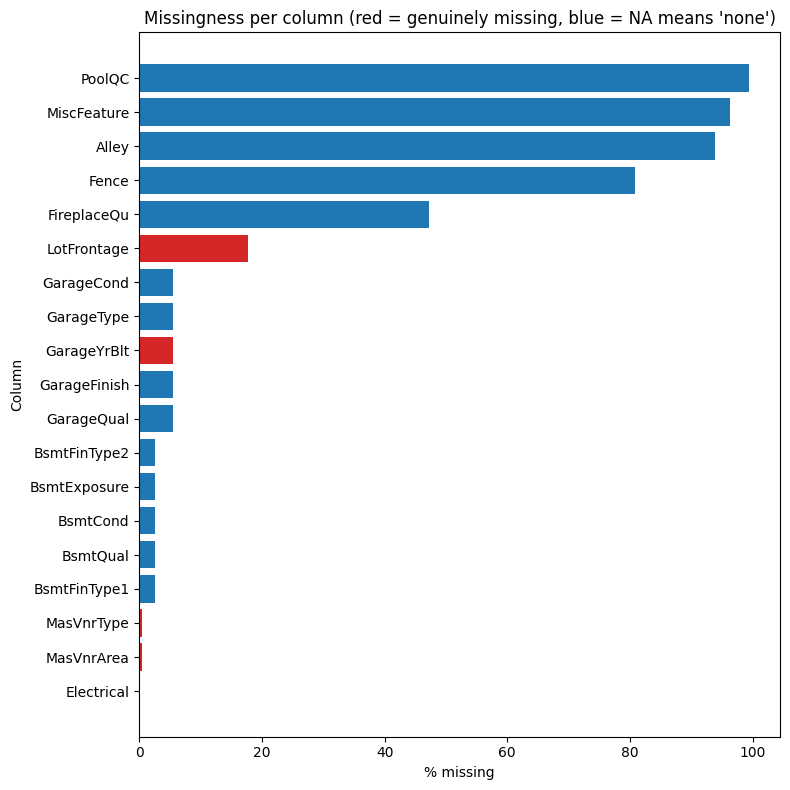

In [10]:
# Columns where data_description.txt documents NA as a real level (not missing data)
NA_IS_CATEGORY = [
    "Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "PoolQC", "Fence", "MiscFeature",
]

missing = train.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(1)

missing_df = pd.DataFrame({"n_missing": missing, "pct_missing": missing_pct})
missing_df["true_missing"] = ~missing_df.index.isin(NA_IS_CATEGORY)

fig, ax = plt.subplots(figsize=(8, 8))
colors = missing_df["true_missing"].map({True: "tab:red", False: "tab:blue"})
ax.barh(missing_df.index[::-1], missing_df["pct_missing"][::-1], color=colors[::-1])
ax.set_xlabel("% missing")
ax.set_ylabel("Column")
ax.set_title("Missingness per column (red = genuinely missing, blue = NA means 'none')")
plt.tight_layout()
plt.show()

# missing_df


**Bug found & fixed:** `read_csv`'s default NA tokens include the literal string `"None"`. `MasVnrType` uses `"None"` as a real documented category ("no masonry veneer"), so the default load silently miscoded 864 valid rows as missing (872 total vs. the true 8).

## 4. Descriptive stats & sanity checks

`describe()` for scale, impossible values (e.g. `YearBuilt > YrSold`), and zero-inflated numeric columns.


In [11]:
numeric_cols = train.select_dtypes(include="number").columns.drop(["Id", "SalePrice"])
train[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


In [12]:
# Impossible/implausible value checks
checks = {
    "YearBuilt > YrSold": train["YearBuilt"] > train["YrSold"],
    "YearRemodAdd > YrSold": train["YearRemodAdd"] > train["YrSold"],
    "GarageYrBlt > YrSold": train["GarageYrBlt"] > train["YrSold"],
    "YearRemodAdd < YearBuilt": train["YearRemodAdd"] < train["YearBuilt"],
    "GarageYrBlt > 2010 (future/typo)": train["GarageYrBlt"] > 2010,
}
for name, mask in checks.items():
    n = mask.sum()
    print(f"{name}: {n} row(s)")
    if n:
        print(train.loc[mask, ["YearBuilt", "YearRemodAdd", "GarageYrBlt", "YrSold"]])


YearBuilt > YrSold: 0 row(s)
YearRemodAdd > YrSold: 1 row(s)
     YearBuilt  YearRemodAdd  GarageYrBlt  YrSold
523       2007          2008       2007.0    2007
GarageYrBlt > YrSold: 0 row(s)
YearRemodAdd < YearBuilt: 0 row(s)
GarageYrBlt > 2010 (future/typo): 0 row(s)


In [13]:
# Zero-inflated numeric columns (many rows at exactly 0)
zero_pct = (train[numeric_cols] == 0).mean().sort_values(ascending=False) * 100
zero_pct = zero_pct[zero_pct > 0].round(1)
zero_pct.to_frame("pct_zero")


,pct_zero
PoolArea,99.5
3SsnPorch,98.4
LowQualFinSF,98.2
MiscVal,96.4
BsmtHalfBath,94.4
ScreenPorch,92.1
BsmtFinSF2,88.6
EnclosedPorch,85.8
HalfBath,62.5
MasVnrArea,59.0


**Findings:**
- Numeric columns span very different scales (`LotArea` up to ~215k vs. `OverallQual` 1–10) — irrelevant for the tree-based `HistGradientBoostingRegressor`, but would need scaling for `Ridge`.
- One minor anomaly: row 523 has `YearRemodAdd` (2008) one year after `YrSold` (2007). Not impossible, not fixed — just noted.
- No `GarageYrBlt` typo in `train.csv` (the well-known Ames `2207` value lives in `test.csv` — check in step 10).
- Several columns are heavily zero-inflated (`PoolArea` 99.5%, `3SsnPorch` 98.4%, `MiscVal` 96.4%, `ScreenPorch` 92.1%, ...). These behave more like "has this feature" flags than continuous measures. Out of scope for the MVP pipeline, but a candidate for a future binary-flag feature.


## 5. Dtype pass

Catch numeric-coded categoricals — `int64` columns whose values are really labels, not quantities, so they must not be treated as ordinal/continuous by the model.


In [14]:
# Low-cardinality int64 columns are the suspects for "numeric code that is really a category"
int_cols = train.select_dtypes(include="int64").columns.drop(["Id", "SalePrice"])
card = train[int_cols].nunique().sort_values()
card[card <= 15]


BsmtHalfBath     3
HalfBath         3
FullBath         4
BsmtFullBath     4
Fireplaces       4
KitchenAbvGr     4
GarageCars       5
YrSold           5
PoolArea         8
BedroomAbvGr     8
OverallCond      9
OverallQual     10
MoSold          12
TotRmsAbvGrd    12
MSSubClass      15
dtype: int64

In [15]:
print(train["MSSubClass"].nunique(), "distinct MSSubClass codes:")
print(sorted(train["MSSubClass"].unique()))


15 distinct MSSubClass codes:
[np.int64(20), np.int64(30), np.int64(40), np.int64(45), np.int64(50), np.int64(60), np.int64(70), np.int64(75), np.int64(80), np.int64(85), np.int64(90), np.int64(120), np.int64(160), np.int64(180), np.int64(190)]


**Findings:**
- All other low-cardinality `int64` columns (`OverallQual`, `OverallCond`, bath/room/fireplace counts, `GarageCars`, `MoSold`, `YrSold`, `PoolArea`) are genuine counts or ordinal scales — fine as numeric.
- `MSSubClass` is the one true offender: its 15 codes (20, 30, ..., 190) are nominal dwelling-type labels with no ordinal meaning — code 60 ("2-Story 1946+") isn't "more" than code 20 ("1-Story 1946+"). Left as `int64`, the numeric branch of the `ColumnTransformer` would median-impute and treat it as a continuous/ordinal quantity, which is meaningless here.

**For `ml.py`:** cast `MSSubClass` to string (or explicitly route it to the categorical column list) before the `ColumnTransformer` split, so it goes through `OneHotEncoder` like the other nominal columns.


## 6. Univariate distributions

Histograms for a few key numerics, bar charts for a few key categoricals.


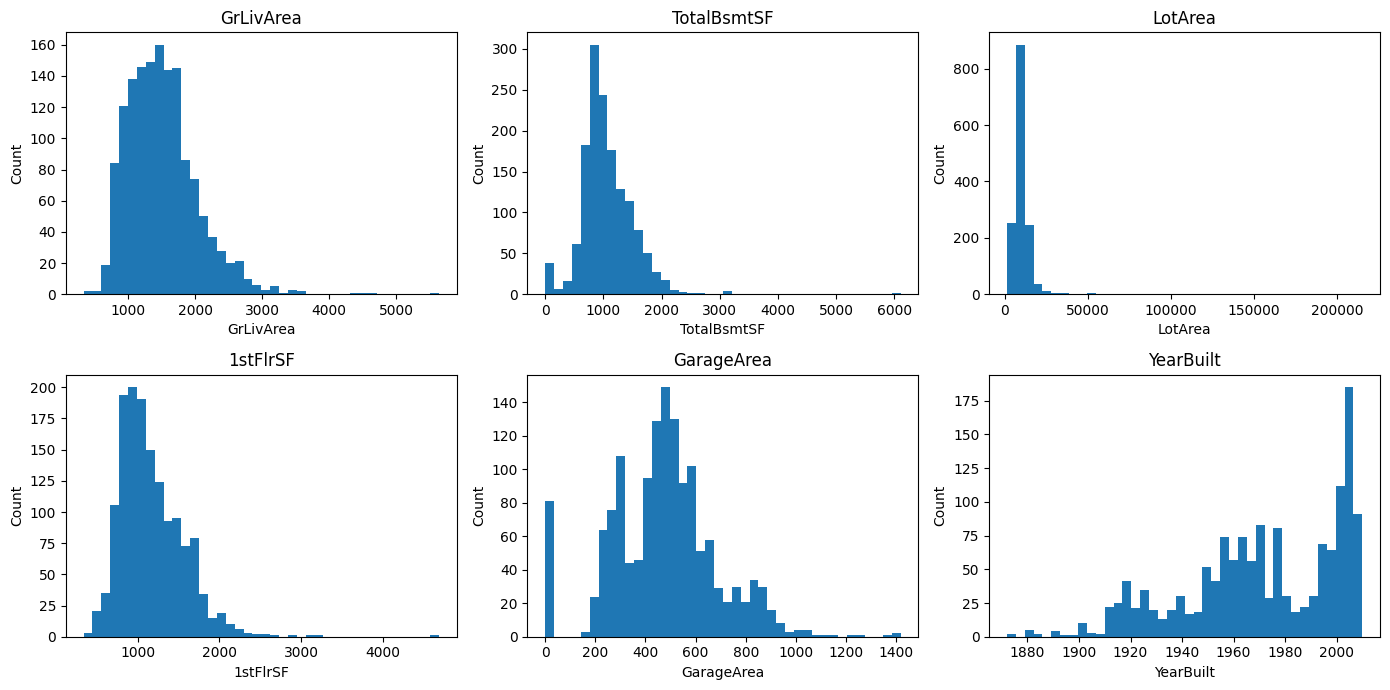

In [16]:
key_numeric = ["GrLivArea", "TotalBsmtSF", "LotArea", "1stFlrSF", "GarageArea", "YearBuilt"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), key_numeric):
    ax.hist(train[col], bins=40)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


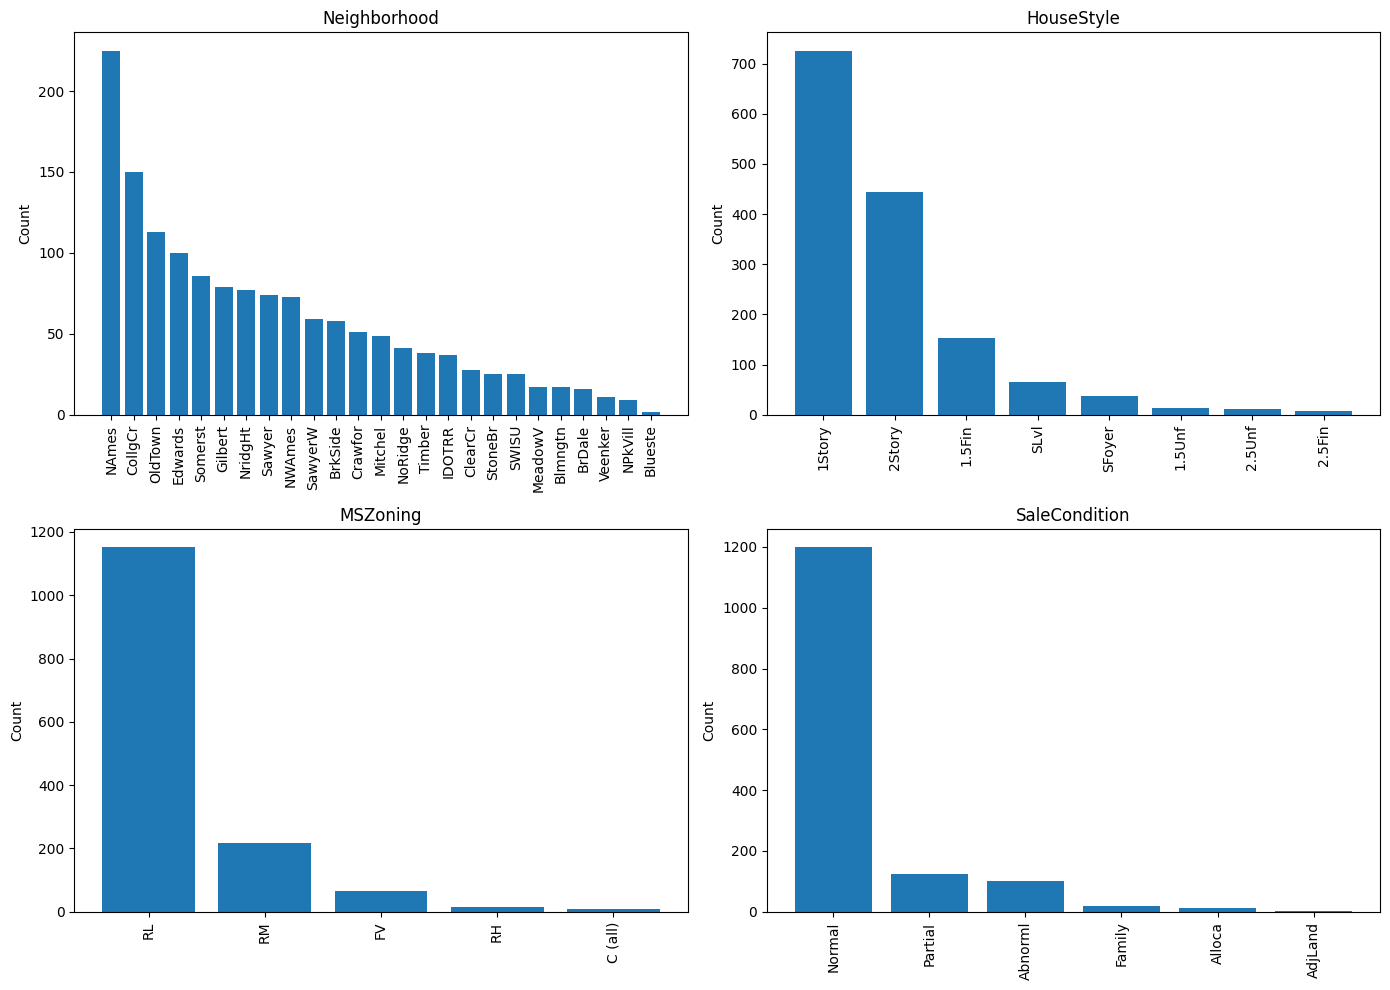

In [17]:
key_categorical = ["Neighborhood", "HouseStyle", "MSZoning", "SaleCondition"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), key_categorical):
    counts = train[col].value_counts()
    ax.bar(counts.index, counts.values)
    ax.set_title(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()


**Findings:** `GrLivArea`/`TotalBsmtSF`/`LotArea` are right-skewed (a few very large houses/lots) — consistent with the zero-inflation and scale findings from step 4. `Neighborhood` and `MSZoning` are dominated by a few common categories with a long tail of rare ones (`OneHotEncoder` handles this fine; no action needed). Nothing here changes the plan.


## 7. Numeric features vs target

Correlation of each numeric feature with `SalePrice`, plus a heatmap among the top movers to check for redundancy/multicollinearity.


In [18]:
target_corr = train[list(numeric_cols) + ["SalePrice"]].corr()["SalePrice"].drop("SalePrice")
target_corr = target_corr.sort_values(ascending=False)
print("Top 10 positive correlations with SalePrice:")
print(target_corr.head(10))
print("\nTop 5 negative correlations with SalePrice:")
print(target_corr.tail(5))


Top 10 positive correlations with SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

Top 5 negative correlations with SalePrice:
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


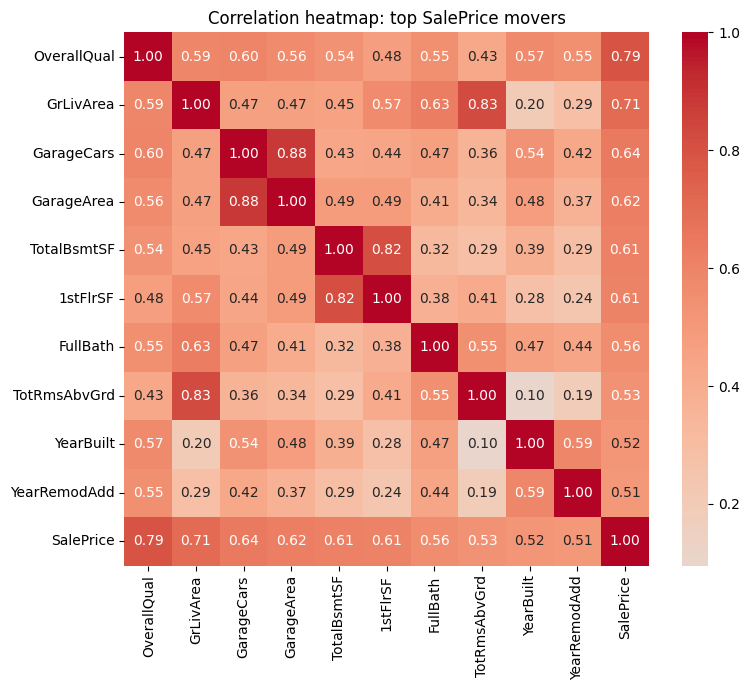

In [19]:
top_features = target_corr.abs().sort_values(ascending=False).head(10).index.tolist()
corr_matrix = train[top_features + ["SalePrice"]].corr()

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation heatmap: top SalePrice movers")
plt.tight_layout()
plt.show()


**Findings:** `OverallQual` (0.79) and `GrLivArea` (0.71) are by far the strongest linear predictors of `SalePrice`. Several top movers are highly correlated with each other, not just the target — `GarageCars`/`GarageArea` (0.88) and `TotalBsmtSF`/`1stFlrSF` (0.82) are near-redundant pairs. Not a problem for `HistGradientBoostingRegressor` (trees are robust to multicollinearity) or for `Ridge` (L2 handles correlated features gracefully) — no feature needs to be dropped for the MVP, just noting it so a surprising `Ridge` coefficient later isn't mistaken for a bug.


## 8. Categorical features vs target

Boxplots of `SalePrice` grouped by a few high-signal categoricals.


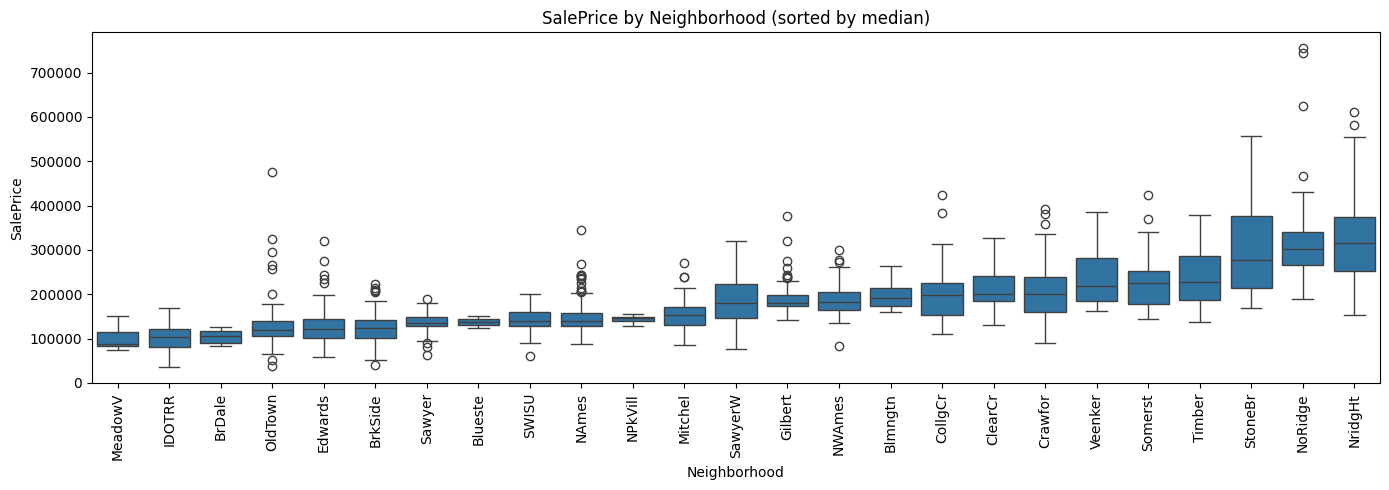

In [20]:
fig, ax = plt.subplots(figsize=(14, 5))
order = train.groupby("Neighborhood")["SalePrice"].median().sort_values().index
sns.boxplot(data=train, x="Neighborhood", y="SalePrice", order=order, ax=ax)
ax.tick_params(axis="x", rotation=90)
ax.set_title("SalePrice by Neighborhood (sorted by median)")
plt.tight_layout()
plt.show()


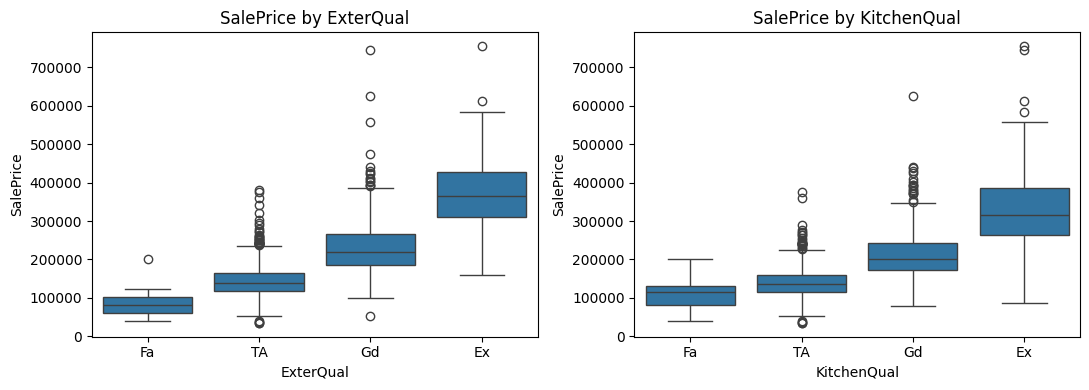

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
qual_order = ["Fa", "TA", "Gd", "Ex"]
sns.boxplot(data=train, x="ExterQual", y="SalePrice", order=qual_order, ax=axes[0])
axes[0].set_title("SalePrice by ExterQual")
sns.boxplot(data=train, x="KitchenQual", y="SalePrice", order=qual_order, ax=axes[1])
axes[1].set_title("SalePrice by KitchenQual")
plt.tight_layout()
plt.show()


**Findings:** `Neighborhood` median price ranges ~3.6x from cheapest (`MeadowV`, $88k) to most expensive (`NridgHt`, $315k), and `ExterQual`/`KitchenQual` show a clean monotonic step up from `Fa` → `Ex`. All three carry real signal and justify their place in the categorical/ordinal feature set as-is.


## 9. Outliers

The well-known Ames outliers: very large `GrLivArea` sold at a surprisingly low `SalePrice`.


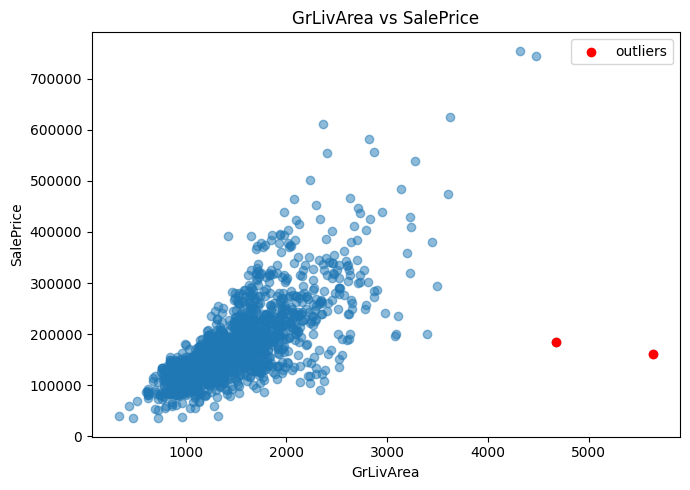

,Id,GrLivArea,SalePrice,OverallQual,SaleCondition
523,524,4676,184750,10,Partial
1298,1299,5642,160000,10,Partial


In [22]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(train["GrLivArea"], train["SalePrice"], alpha=0.5)
outliers = train[(train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)]
ax.scatter(outliers["GrLivArea"], outliers["SalePrice"], color="red", label="outliers")
ax.set_xlabel("GrLivArea")
ax.set_ylabel("SalePrice")
ax.set_title("GrLivArea vs SalePrice")
ax.legend()
plt.tight_layout()
plt.show()

outliers[["Id", "GrLivArea", "SalePrice", "OverallQual", "SaleCondition"]]


**Findings:** Two rows (`Id` 524, 1299) have `GrLivArea` > 4000 sqft but sold under $200k despite `OverallQual`=10 — the textbook Ames outliers most public writeups drop before training. Both are `SaleCondition="Partial"` (new construction, sold before completion), which plausibly explains the below-market price. **Decision:** drop these two rows before fitting (not at ingest time — keep raw data intact per PLAN.md's "process after DB" design; drop inside the training step only).


## 10. Train/test consistency

Categorical levels present in `test.csv` but absent from `train.csv` (validates the `OneHotEncoder(handle_unknown="ignore")` decision), plus a check for the known `GarageYrBlt` typo.


In [23]:
categorical_cols = train.select_dtypes(include=["object", "str"]).columns.tolist() + ["MSSubClass"]

unseen_levels = {}
for col in categorical_cols:
    train_levels = set(train[col].dropna().unique())
    test_levels = set(test[col].dropna().unique())
    extra = test_levels - train_levels
    if extra:
        unseen_levels[col] = extra

print("Columns with test-only categorical levels:", len(unseen_levels))
for col, levels in unseen_levels.items():
    print(f"  {col}: {levels}")


Columns with test-only categorical levels: 1
  MSSubClass: {np.int64(150)}


In [24]:
print("GarageYrBlt max in train:", train["GarageYrBlt"].max())
print("GarageYrBlt max in test: ", test["GarageYrBlt"].max())
test[test["GarageYrBlt"] > 2010][["Id", "GarageYrBlt", "YearBuilt", "YrSold"]]


GarageYrBlt max in train: 2010.0
GarageYrBlt max in test:  2207.0


,Id,GarageYrBlt,YearBuilt,YrSold
1132,2593,2207.0,2006,2007


**Findings:**
- Only one categorical column has a level in `test.csv` unseen in `train.csv`: `MSSubClass` code `150` — confirms `OneHotEncoder(handle_unknown="ignore")` is not optional, as PLAN.md already assumed.
- The known Ames `GarageYrBlt` typo is real: test row `Id=2593` has `GarageYrBlt=2207` (`YearBuilt` 2006, `YrSold` 2007 — clearly meant `2007`). It's in `test.csv`, not `train.csv`, so it won't corrupt training, but it demonstrates that arbitrary future `POST /predict` rows can contain nonsensical values — the pipeline must not crash on them (it won't: `GarageYrBlt` just flows through the numeric imputer/model like any other number, no explicit range validation exists or is needed for MVP).


## 11. Insights & decisions

Concrete choices for `backend/app/ml.py`, derived from the steps above:

1. **Target**: train on `log1p(SalePrice)`, report RMSE on the log scale, `expm1()` for display — target is heavily right-skewed (skew 1.88), log form is near-normal (skew 0.12).
2. **Load with `na_values=["NA"], keep_default_na=False`** — pandas' default NA-token list includes the literal string `"None"`, which collides with `MasVnrType`'s real `"None"` category. Applies to any CSV ingested via `POST /datasets/from-url`, not just this notebook.
3. **NA-as-category columns** (14): `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`, `Garage{Type,Finish,Qual,Cond}`, `Bsmt{Qual,Cond,Exposure,FinType1,FinType2}` → fill with an explicit `"None"` string before/instead of `SimpleImputer`.
4. **Genuinely-missing columns** (5): `LotFrontage`, `GarageYrBlt`, `MasVnrType`, `MasVnrArea`, `Electrical` → standard `SimpleImputer` (median / most-frequent) as already planned.
5. **`MSSubClass`** must be treated as categorical (cast to string / routed to the categorical column list), not numeric — its integer codes are nominal labels with no ordinal meaning.
6. **`OneHotEncoder(handle_unknown="ignore")` is required, not optional** — `test.csv` contains an `MSSubClass` level (`150`) absent from `train.csv`; any future user-supplied dataset can do the same at predict time.
7. **Drop 2 outlier rows** at training time only (`Id` 524, 1299 — `GrLivArea` > 4000, `SalePrice` < $200k, both `SaleCondition="Partial"`). Keep raw stored data untouched; filter inside the training step.
8. **No feature needs dropping** despite `GarageCars`/`GarageArea` (r=0.88) and `TotalBsmtSF`/`1stFlrSF` (r=0.82) being near-redundant — both the tree model and `Ridge` tolerate multicollinearity fine for this dataset size.
9. **No explicit range/sanity validation needed in `POST /predict`** — arbitrary numeric values (e.g. the real `GarageYrBlt=2207` typo found in `test.csv`) flow harmlessly through imputation + model without crashing.
